In [21]:
%matplotlib inline

import os, pathlib
import pickle
from importlib import reload
import logging, warnings
logging.basicConfig(level=logging.ERROR)
warnings.simplefilter("ignore")

import PyPDF2 as ppdf
import numpy as np
from sklearn.decomposition import PCA
import scipy.linalg as linalg
from sklearn.model_selection import KFold
from scipy.stats import wilcoxon, linregress
from IPython.display import clear_output

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.lines as mlines
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

import pyaldata as pyal

if "__file__" not in dir():
    try:
        NBPath = pathlib.Path.cwd()
        RepoPath = NBPath.parent
        os.chdir(RepoPath)

        from tools import utilityTools as utility
        from tools import dataTools as dt
        from tools import ccaTools as cca
        from tools import rasterTools as rt
        import params
        monkey_defs = params.monkey_defs

        set_rc =  params.set_rc_params
        set_rc()
        root = params.root

        os.chdir(RepoPath / 'monkey')
        %run "_dataset-selection.ipynb"

    finally:
        os.chdir(NBPath)
    print('Done')

FIGPATH = params.figPath / 'fig2'
FIGPATH.mkdir(exist_ok=True, parents=True)

Done


### Get data

In [2]:
raster_example_df = dt.get_example_monkey_data(epoch = monkey_defs.exec_epoch)

### Fig 2A: Raster panel

Executed: `plot_fr_raster` in 0.1s
Executed: `plot_fr_raster` in 0.1s
Executed: `plot_pos_ex` in 0.1s
Executed: `plot_pos_ex` in 0.1s


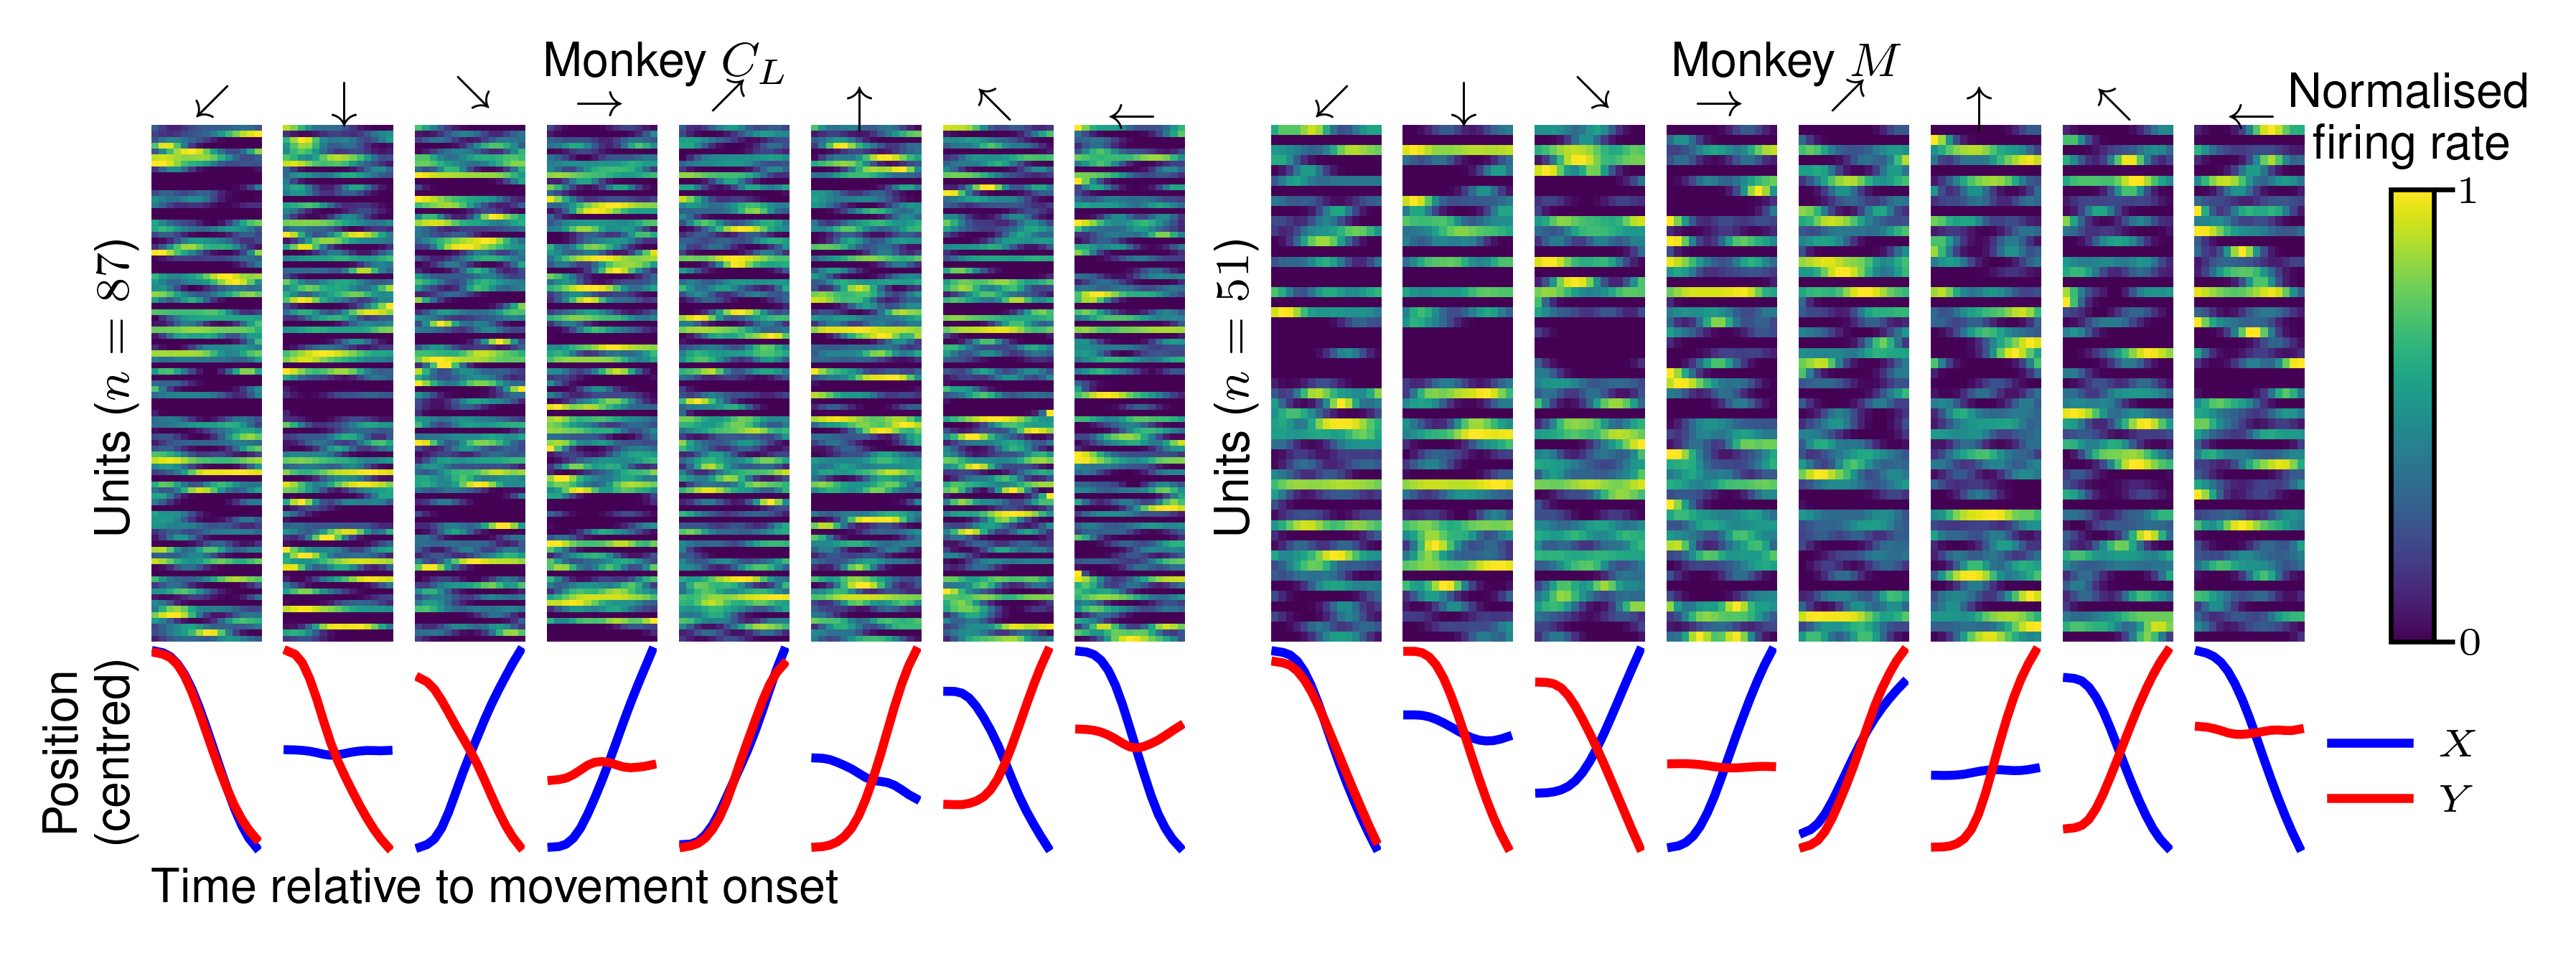

In [3]:
figsize=params.LargeFig
fig=plt.figure(figsize=figsize)

gs2_1 = utility.add_gridspec_abs(fig, nrows=1, ncols=monkey_defs.n_targets,
                                    left=params.panels.schmatic[0],
                                    bottom=figsize[1]-params.panels.schmatic[1]+params.panels.velocity[1],
                                    width=params.panels.raster[0], 
                                    height=params.panels.raster[1])
gs2_2 = utility.add_gridspec_abs(fig, nrows=1, ncols=monkey_defs.n_targets,
                                    right=figsize[0],
                                    top=figsize[1],
                                    width=params.panels.raster[0], 
                                    height=params.panels.raster[1])

gs2_3 = utility.add_gridspec_abs(fig, nrows=1, ncols=monkey_defs.n_targets,
                                    left=params.panels.schmatic[0],
                                    bottom=figsize[1]-params.panels.schmatic[1],
                                    width=params.panels.raster[0], 
                                    height=params.panels.velocity[1])
gs2_4 = utility.add_gridspec_abs(fig, nrows=1, ncols=monkey_defs.n_targets,
                                    right=figsize[0],
                                    top=figsize[1]-params.panels.raster[1],
                                    width=params.panels.raster[0], 
                                    height=params.panels.velocity[1])

# the `gs` object has a `.fig` attribute, so having a `fig` argument in the function signature is a bad practice

axes2_1 = rt.plot_fr_raster(raster_example_df[0], gs2_1, fig, range(monkey_defs.n_targets))
axes2_2 = rt.plot_fr_raster(raster_example_df[1], gs2_2, fig, range(monkey_defs.n_targets))
utility.phantom_axes(fig.add_subplot(gs2_1[:])).set_title('Monkey $C_L$', pad=8)
utility.phantom_axes(fig.add_subplot(gs2_2[:])).set_title('Monkey $M$', pad=8)

axes2_3 = rt.plot_pos_ex(raster_example_df[0], gs2_3, fig, range(monkey_defs.n_targets))
axes2_4 = rt.plot_pos_ex(raster_example_df[1], gs2_4, fig, range(monkey_defs.n_targets))

axes2_3[0].set_ylabel('Position\n(centred)')
axes2_3[0].set_xlabel('Time relative to movement onset',loc='left')
X_line = mlines.Line2D([], [], color='blue', label='$X$')
Y_line = mlines.Line2D([], [], color='red', label='$Y$')
axes2_4[-1].legend(handles=[X_line, Y_line], loc=(1.1,.1))
    
gs2_c = utility.add_gridspec_abs(fig, nrows=1, ncols=1, 
                                    height=params.panels.raster[1]-.15, 
                                    width=.1, 
                                    left=figsize[0]+.2, 
                                    bottom=figsize[1]-params.panels.schmatic[1]+params.panels.velocity[1])
cax2 = fig.add_subplot(gs2_c[:])
fig.colorbar(cm.ScalarMappable(),cax=cax2, ticks=(0,1),drawedges=False)
cax2.set_title('Normalised\nfiring rate')

fig.savefig(FIGPATH / 'rasters.pdf', format='pdf', bbox_inches='tight')


### Fig 2C-E: 3D dynamics panel

In [19]:
@utility.report
def plot_monkey_pc_example(raster_example_df, gs):   
    fig=gs.figure
    
    colors = utility.get_colors(8)
    dfs=[]
    axes=[]
    for i,df in enumerate(raster_example_df):
        rates = np.concatenate(df['M1_rates'].values, axis=0)
        rates_model = PCA(n_components=10, svd_solver='full').fit(rates)
        df_ = pyal.apply_dim_reduce_model(df, rates_model, 'M1_rates', '_pca');
        dfs.append(df_)
        ax = fig.add_subplot(gs[i], projection='3d',fc='None')
        axes.append(ax)
        for tar in range(monkey_defs.n_targets):
            df__ = pyal.select_trials(df_, df_.target_id==tar)
            ex = pyal.get_sig_by_trial(df__,'_pca')
            ex = np.mean(ex, axis=2)[:,:3]
            ax.plot(ex[:,0],ex[:,1],ex[:,2],color=colors[tar],lw=1)
            ax.view_init(60,-47)

    AllData = dt.get_data_array(raster_example_df, area='M1', model=10)
    data1 = np.reshape(AllData[0,...], (-1,10))
    data2 = np.reshape(AllData[1,...], (-1,10))
    A,B,*_ = cca.canoncorr(data1,data2,fullReturn=True)
    coef_ = [A,B]
    for i,sessionData in enumerate(AllData):
        ax = fig.add_subplot(gs[i+3], projection='3d',fc='None')
        U, _, Vh = linalg.svd(coef_[i], full_matrices=False, compute_uv=True, overwrite_a=False, check_finite=False)
        axes.append(ax)
        for tar in range(8):
            ex = np.mean(sessionData[tar,...], axis=0)
            ex = ex @ U @ Vh
            ax.plot(ex[:,0],ex[:,1],ex[:,2],color=colors[tar],lw=1)
            ax.view_init(60,-47)

    titles=[r'Monkey $C_L$ (\textit{unaligned})',r'Monkey $M$ (\textit{unaligned})',
            r'Monkey $C_L$ (\textit{aligned})',  r'Monkey $M$ (\textit{aligned})']
    labels = ['PC','PC','CC','CC']
    for i, ax in enumerate(axes):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.set_xlabel(f'{labels[i]}1', labelpad=-15)
        ax.set_ylabel(f'{labels[i]}2', labelpad=-15)
        ax.set_zlabel(f'{labels[i]}3', labelpad=-15)
        ax.set_title(titles[i], y=.9, loc='center')
    
    #======== add the arrow
    
    ax = fig.add_subplot(gs[2], fc='None')
    ax = utility.phantom_axes(ax)
    ax.arrow(0,0,1,0,length_includes_head=True, width=.005, head_width=.015,head_length=.1, ec='k', fc='k')
    ax.set_ylim([-.1,.1])
    ax.set_xlim([-.5,1.1])
    ax.text(0.5,0.01,'CCA', ha='center', va='bottom')
    ax.text(0.5,-0.01,'(alignment)', ha='center', va='top')
    
    return axes

Executed: `plot_monkey_pc_example` in 0.2s


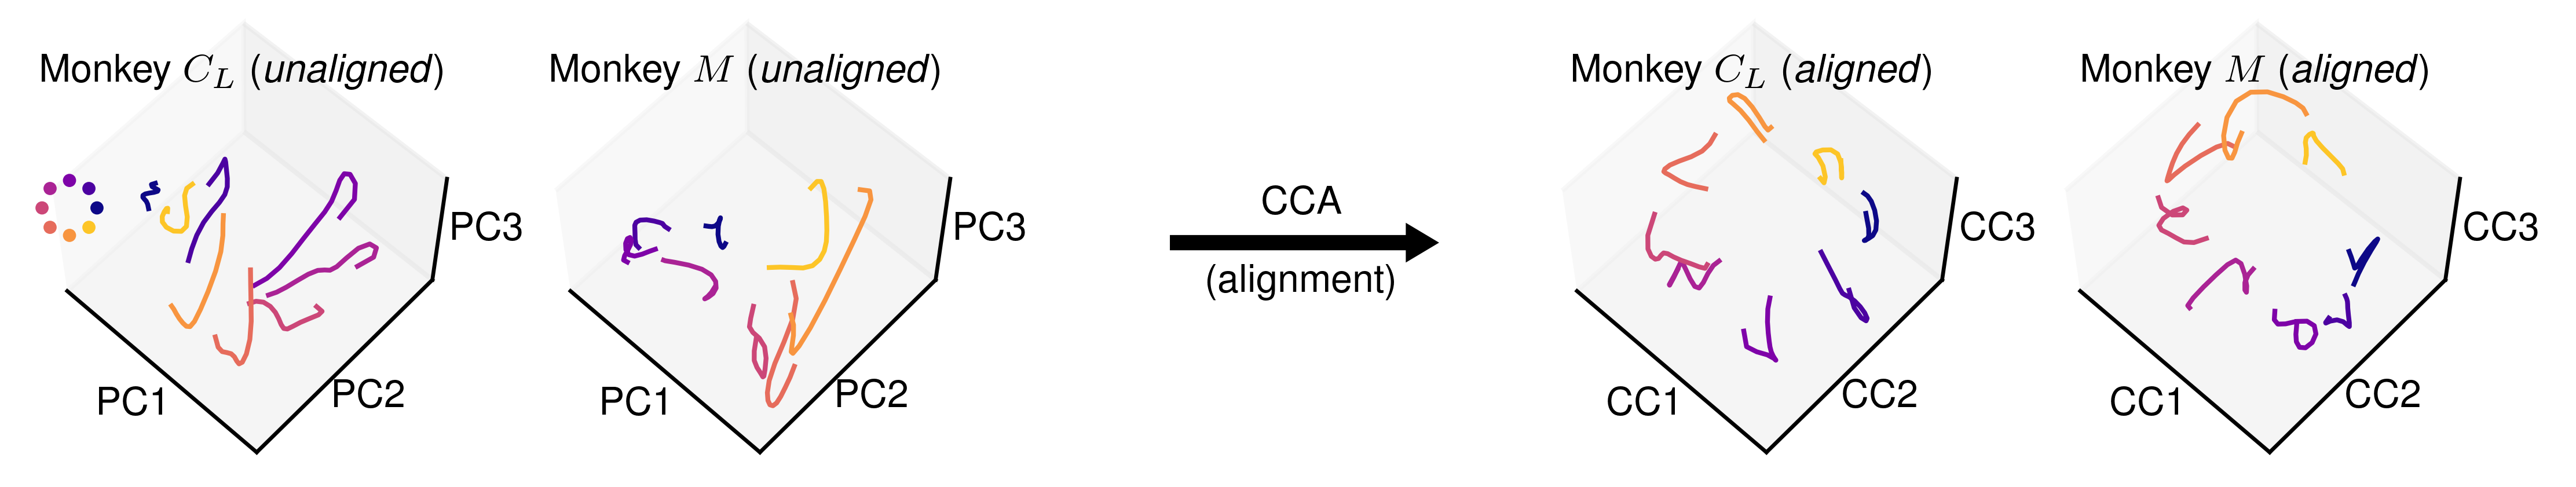

In [22]:
figsize=params.LargeFig
fig=plt.figure(figsize=figsize)
gs3   =utility.add_gridspec_abs(fig, nrows=1, ncols=5, left=0, 
                                bottom=figsize[1]-params.panels.schmatic[1]-params.panels.proj_3d_align[1]-.3,
                                width=params.panels.proj_3d_align[0], 
                                height=params.panels.proj_3d_align[1])

axes3 = plot_monkey_pc_example(raster_example_df, gs3)


gs3_c = utility.add_gridspec_abs(fig, nrows=1, ncols=1, left=0,
                                bottom=(axes3[0].get_position().y0+axes3[0].get_position().y1)/2*figsize[1],
                                width=.2, height=0.2)
cax3 = fig.add_subplot(gs3_c[0],zorder=10)

utility.plot_targets(cax3,3)
cax3.set_xlim(np.array(cax3.get_xlim())*1.15)
cax3.set_ylim(np.array(cax3.get_ylim())*1.15)

fig.savefig(FIGPATH / '3d-dynamics-example.pdf', format='pdf', bbox_inches='tight')


### Fig 2F: CCA for monkey example session

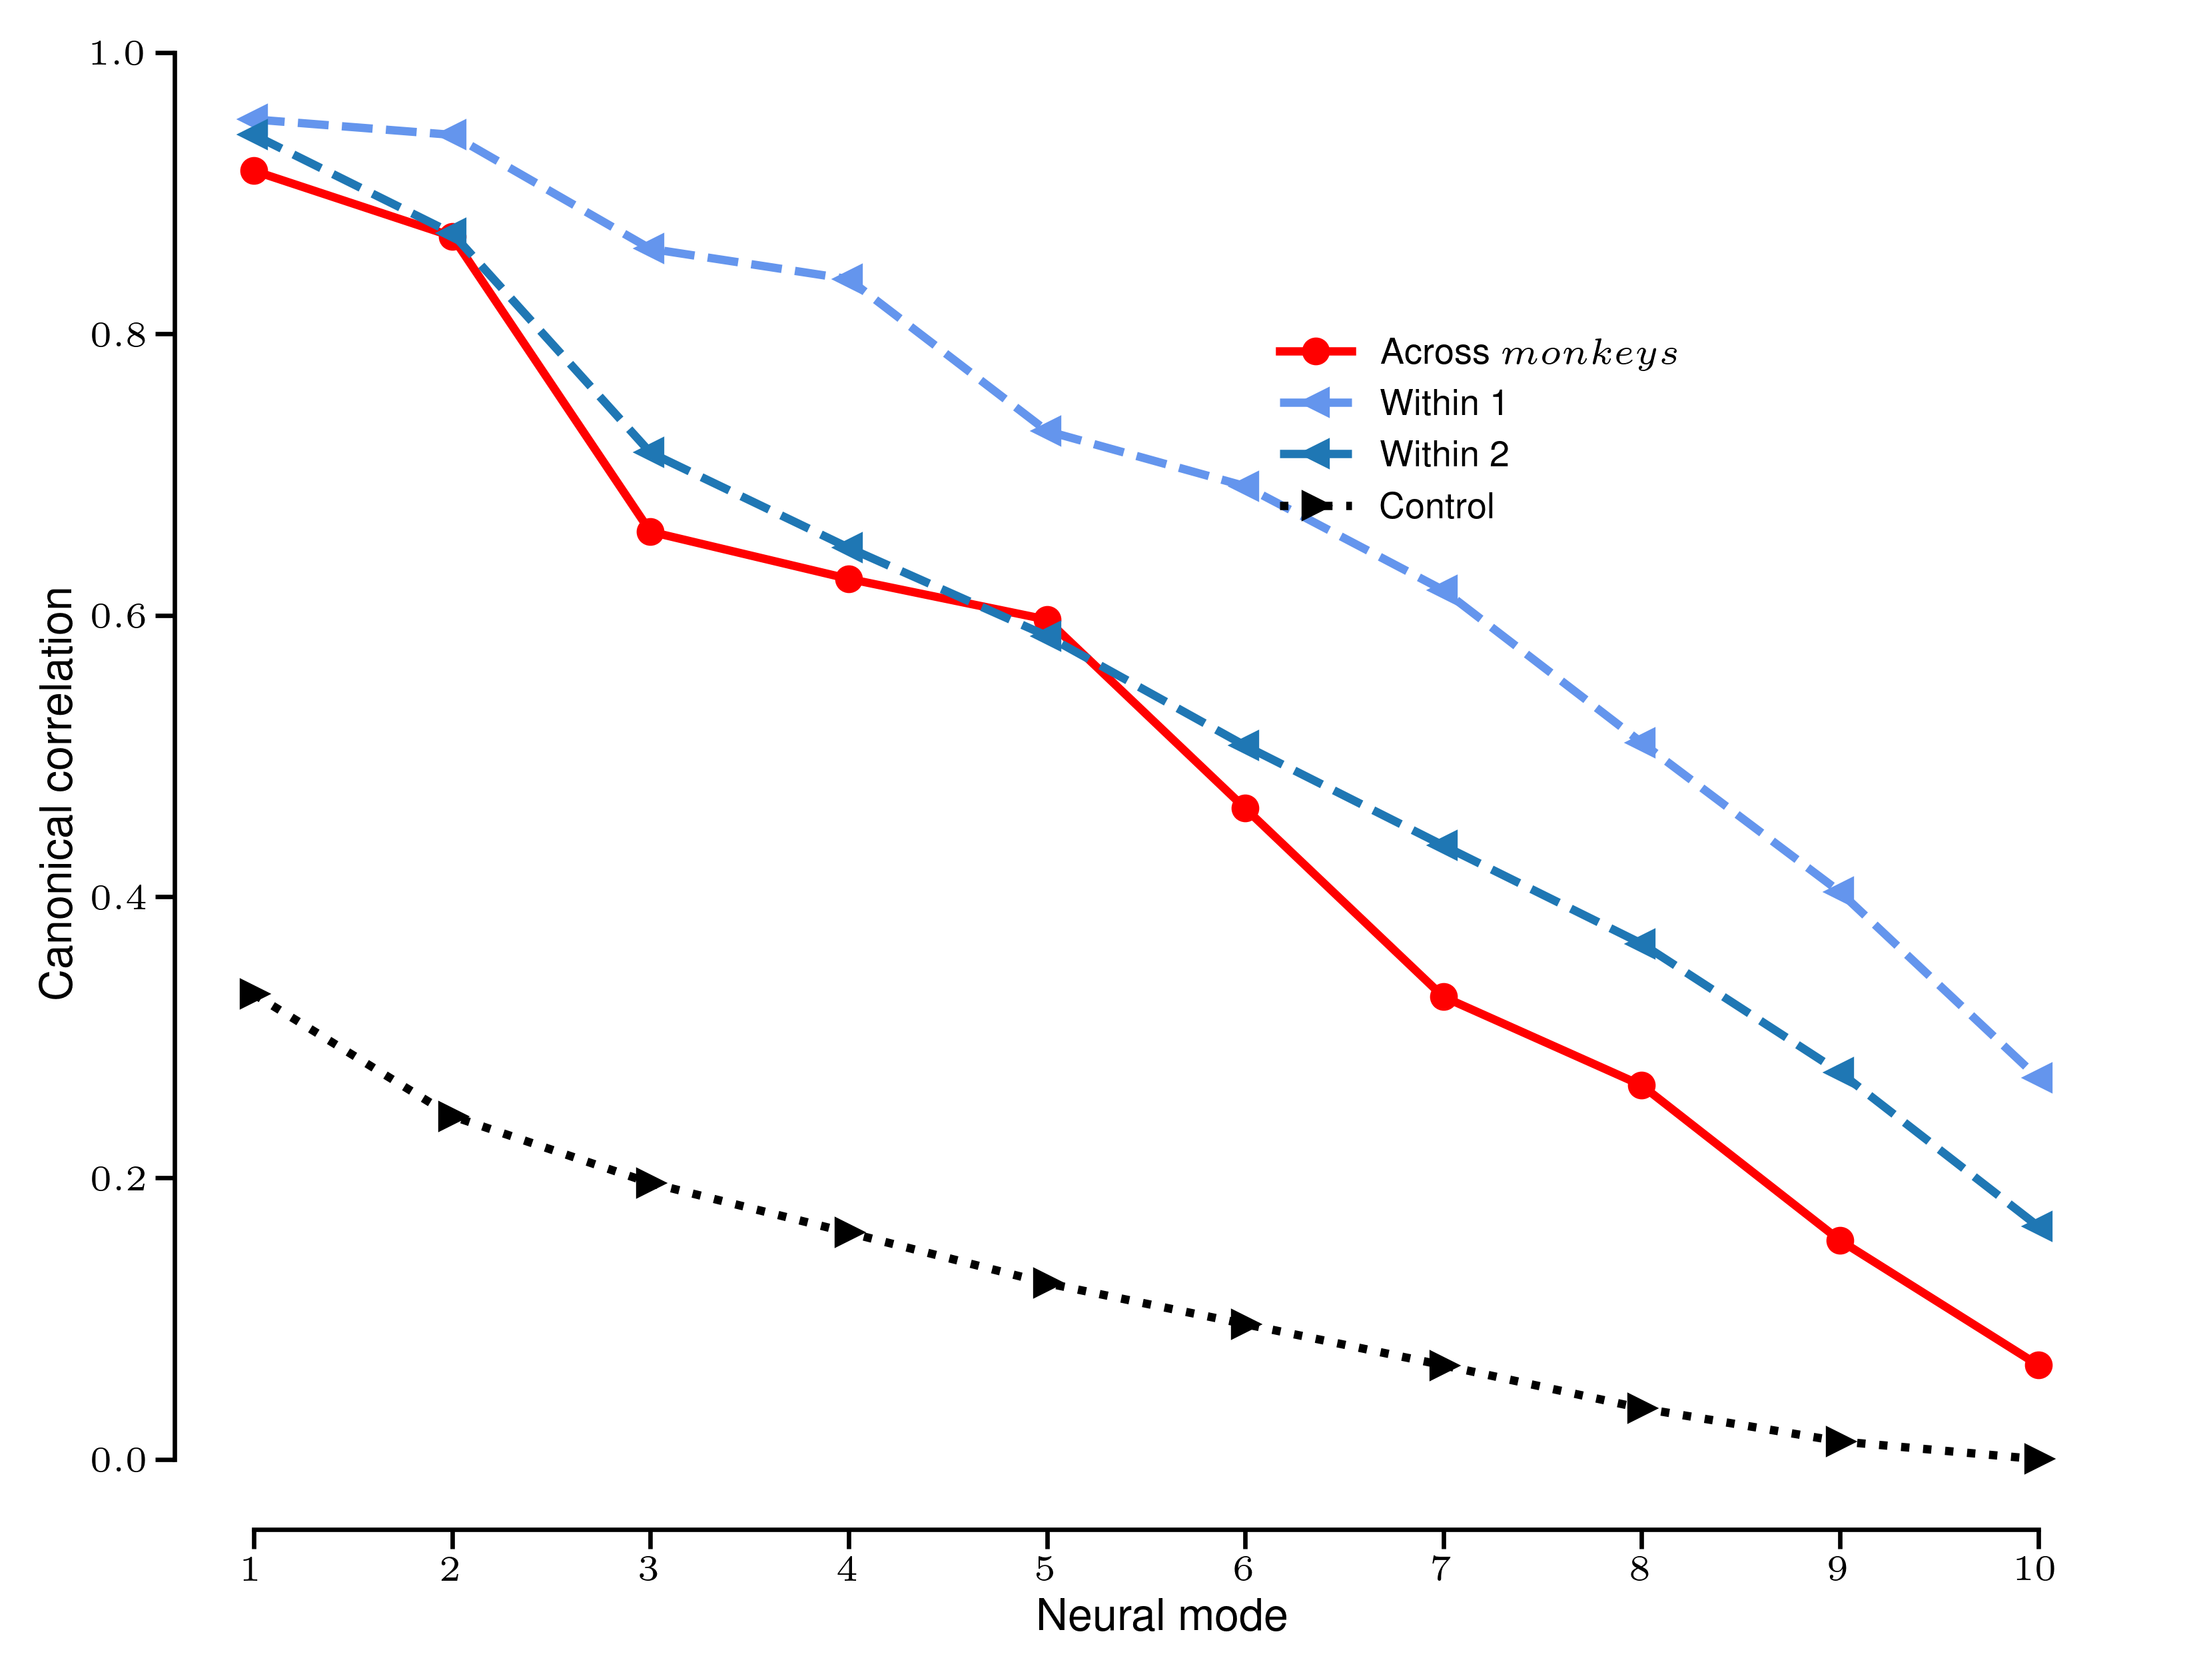

In [24]:
example_dfs = dt.get_example_monkey_data()

fig, ax = plt.subplots()
cca.plot_cca_for_ex(ax, example_dfs, 
                monkey_defs.exec_epoch, 
                monkey_defs.areas[2], 
                monkey_defs.n_components)

fig.savefig(FIGPATH / 'monkey-cca-example.pdf', format='pdf', bbox_inches='tight')